In [ ]:
import pandas as pd
data=pd.read_csv("bank_transactions_data_2.csv")
df=pd.DataFrame(data)
df

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,33,Doctor,109,1,12690.79,2024-11-04 08:11:29
2508,TX002509,AC00322,251.54,2023-03-22 17:36:48,Debit,Tucson,D000410,49.174.157.140,M029,Branch,48,Doctor,177,1,254.75,2024-11-04 08:11:42
2509,TX002510,AC00095,28.63,2023-08-21 17:08:50,Debit,San Diego,D000095,58.1.27.124,M087,Branch,56,Retired,146,1,3382.91,2024-11-04 08:08:39
2510,TX002511,AC00118,185.97,2023-02-24 16:24:46,Debit,Denver,D000634,21.190.11.223,M041,Online,23,Student,19,1,1776.91,2024-11-04 08:12:22


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().value_counts()

,count
False,2512


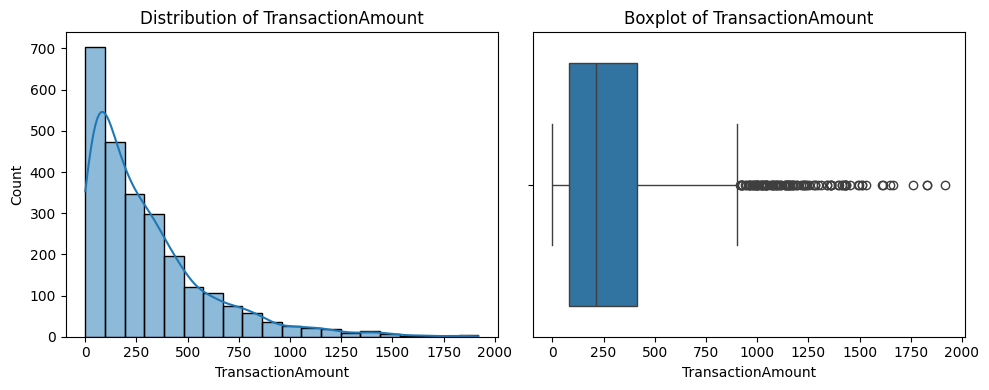

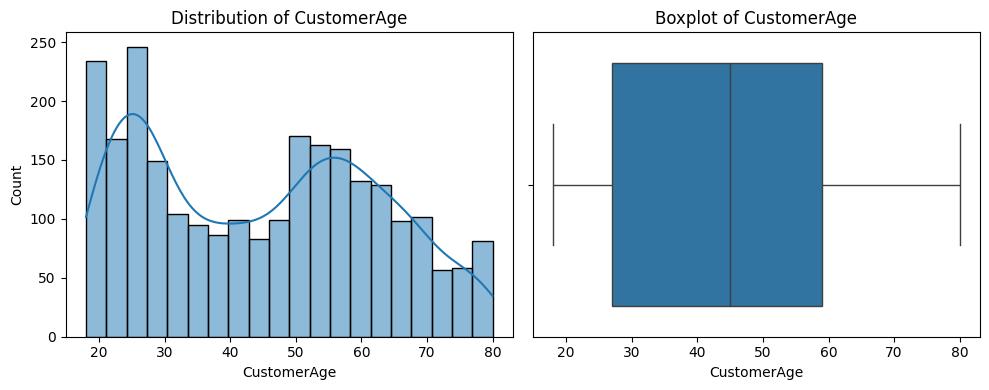

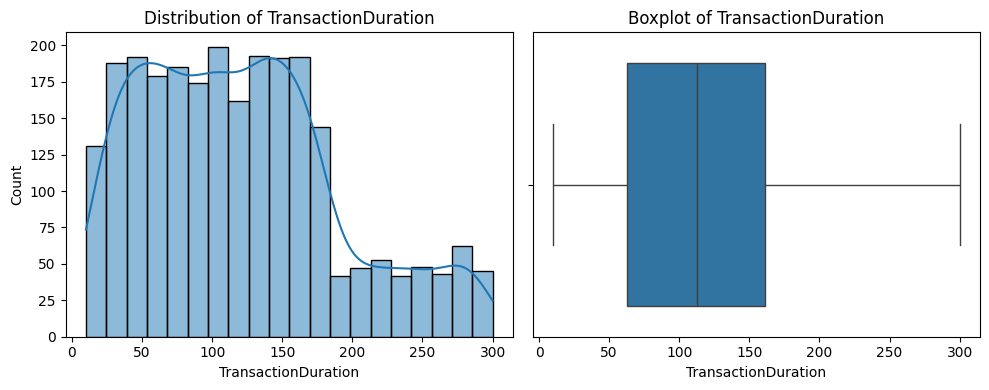

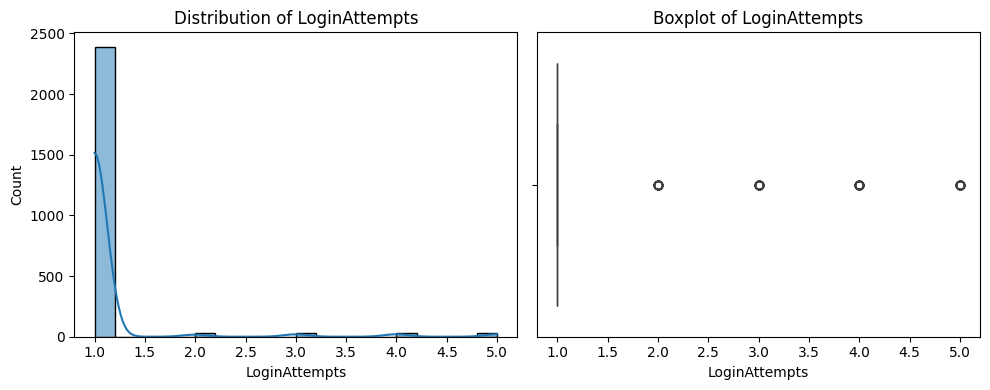

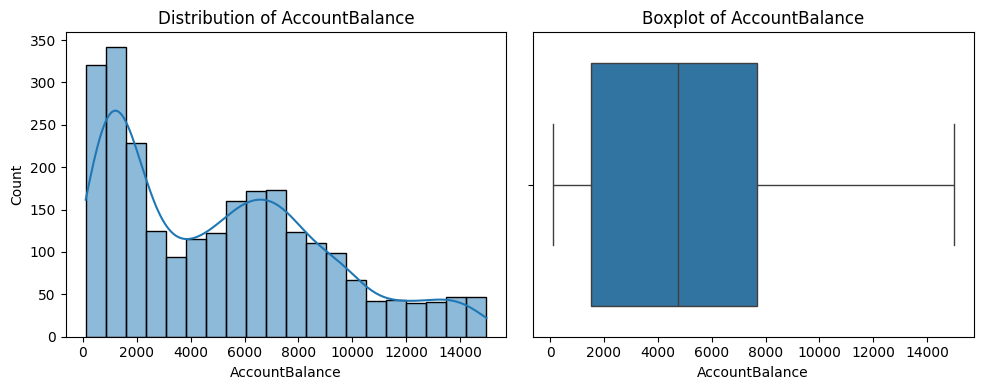

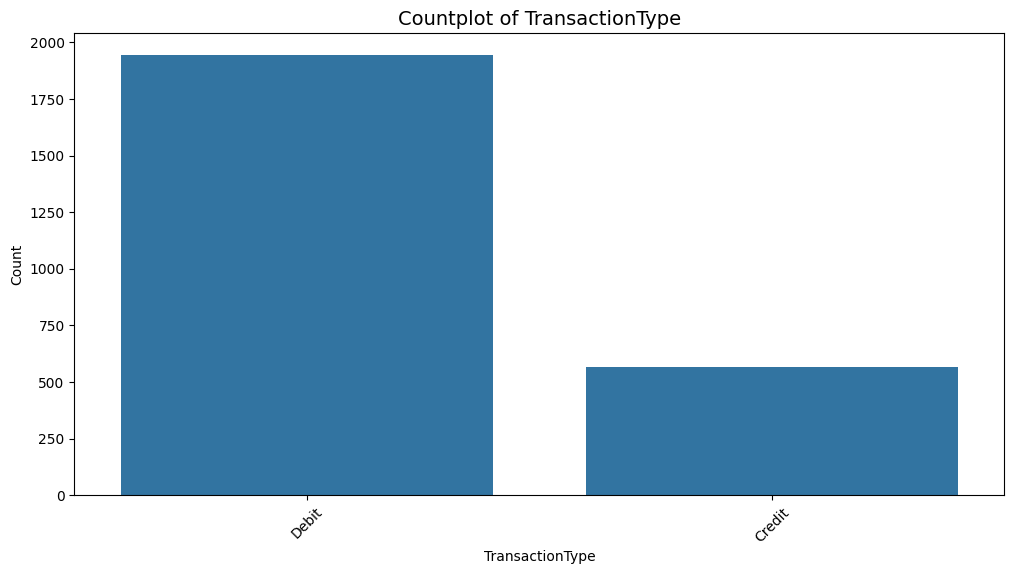

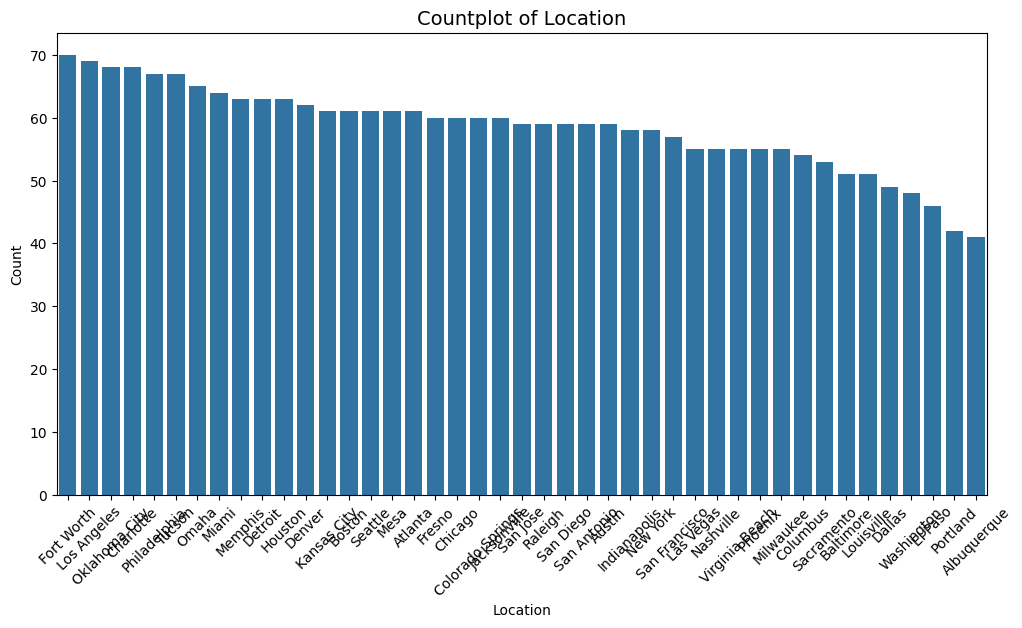

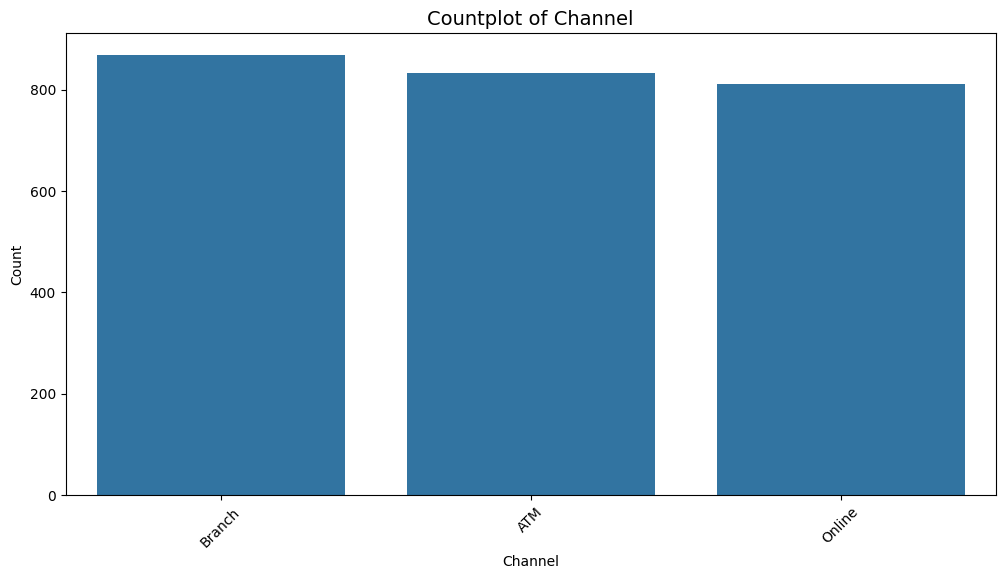

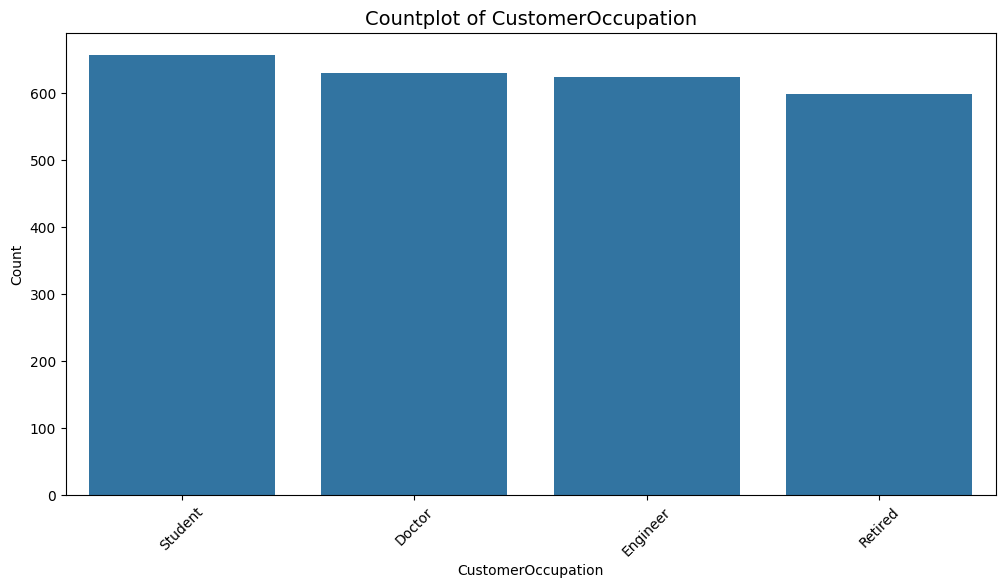

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(data[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

categorical_cols = ['TransactionType', 'Location', 'Channel', 'CustomerOccupation']

for col in categorical_cols:
    plt.figure(figsize=(12, 6))

    sns.countplot(
        x=data[col],
        order=data[col].value_counts().index
    )

    plt.title(f'Countplot of {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

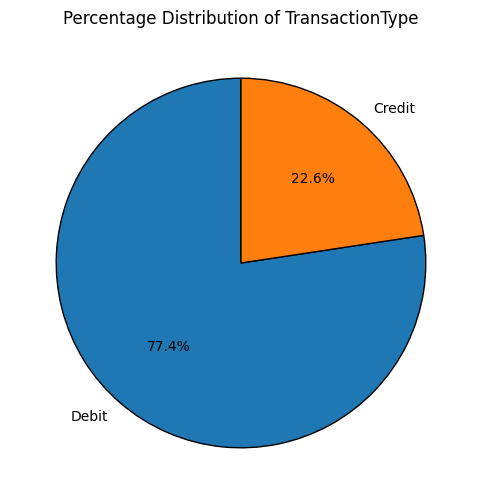

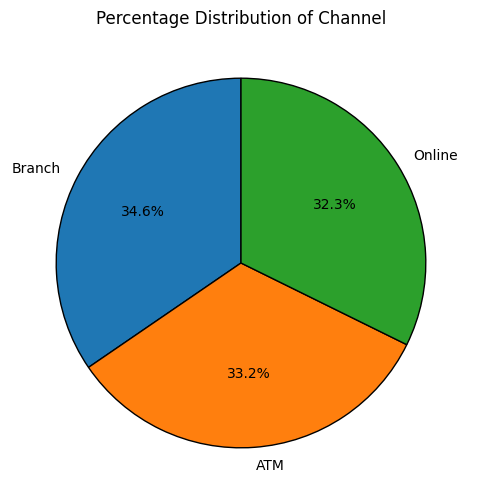

In [ ]:
import matplotlib.pyplot as plt
pie_cols = ['TransactionType', 'Channel']
for col in pie_cols:
    plt.figure(figsize=(6, 6))
    data[col].value_counts().plot.pie(
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'black'}
    )
    plt.title(f'Percentage Distribution of {col}')
    plt.ylabel('')
    plt.show()

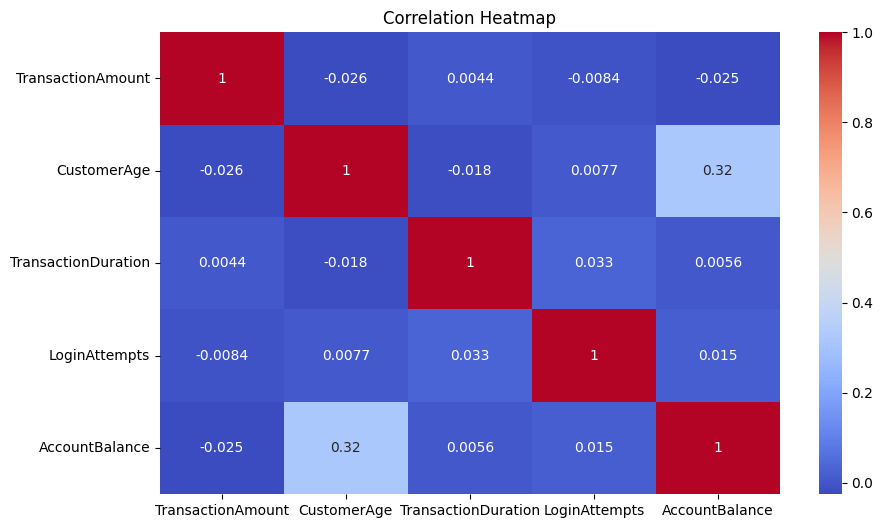

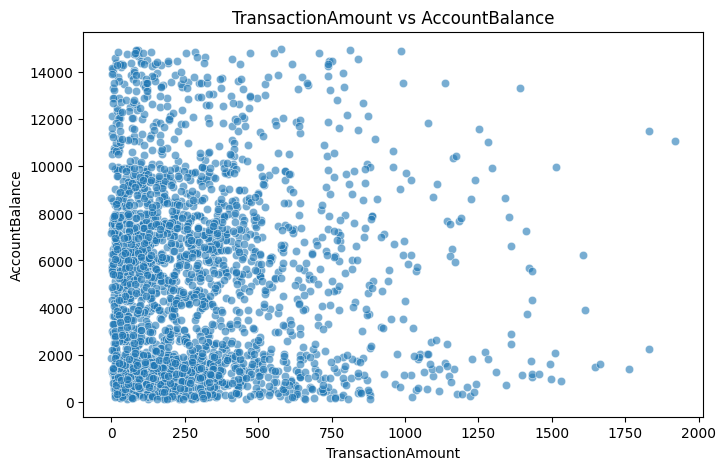

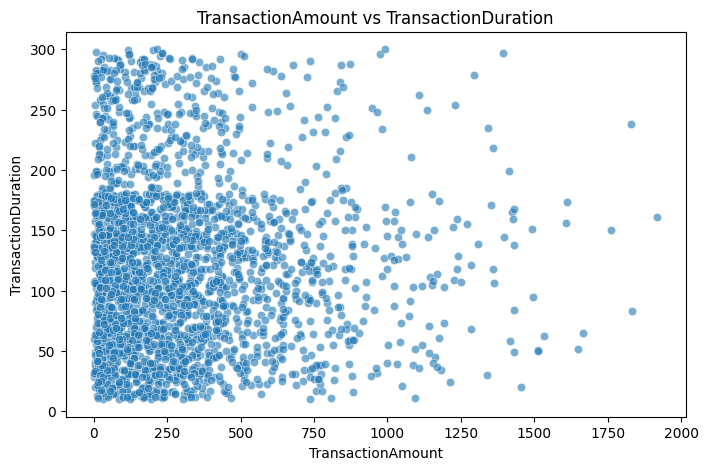

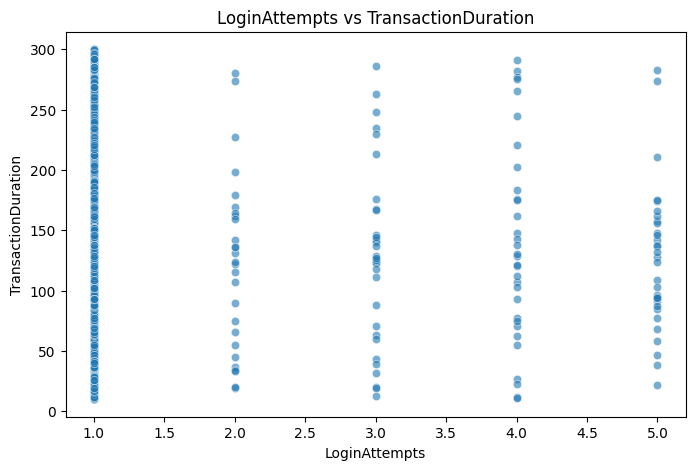

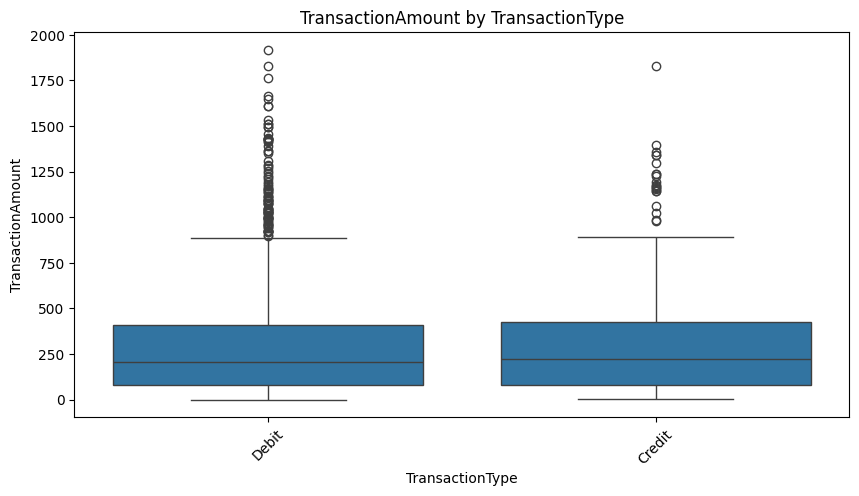

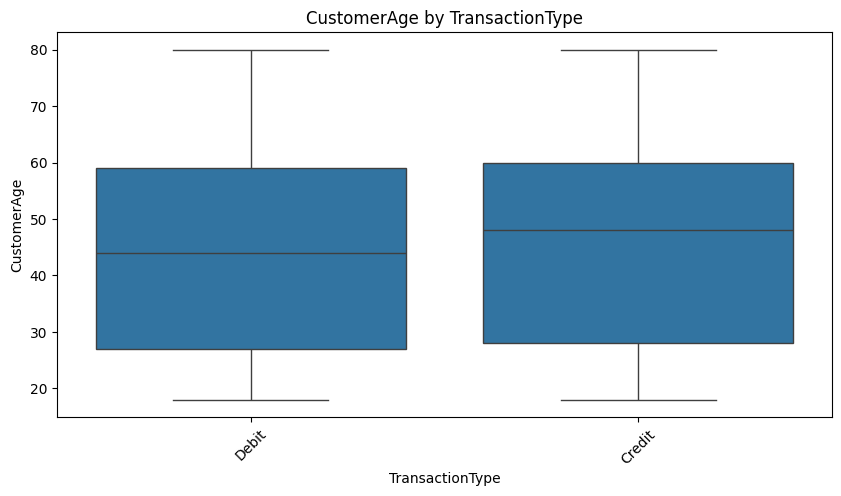

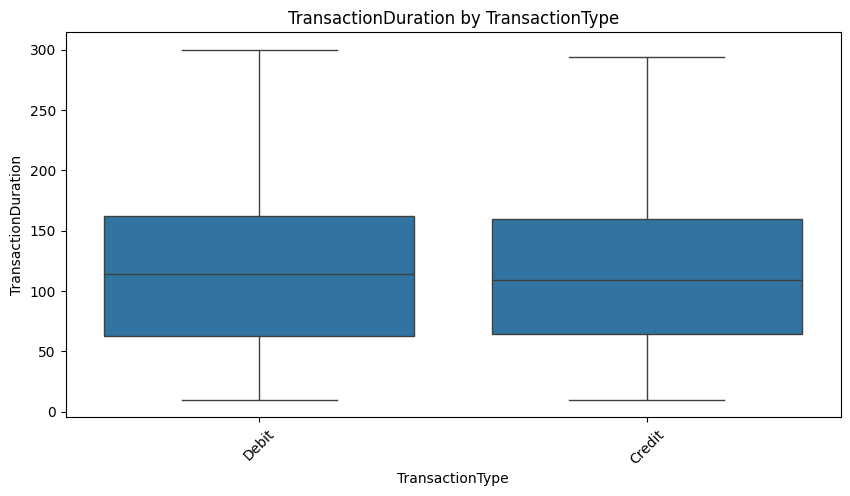

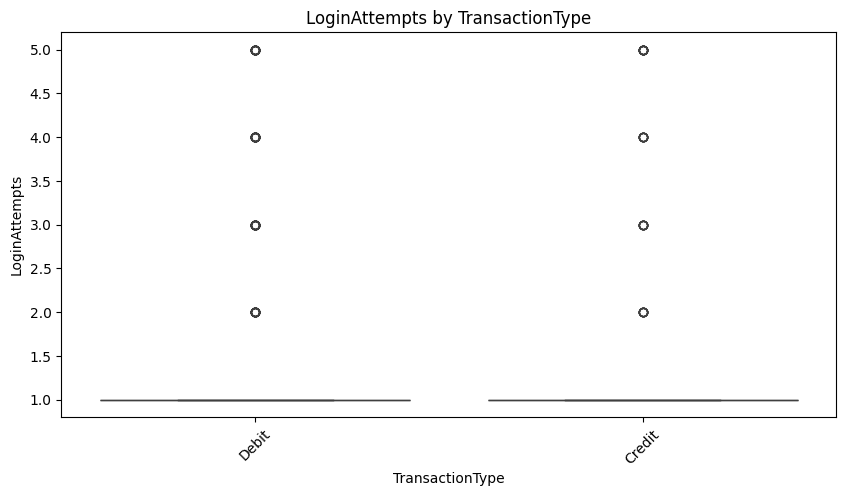

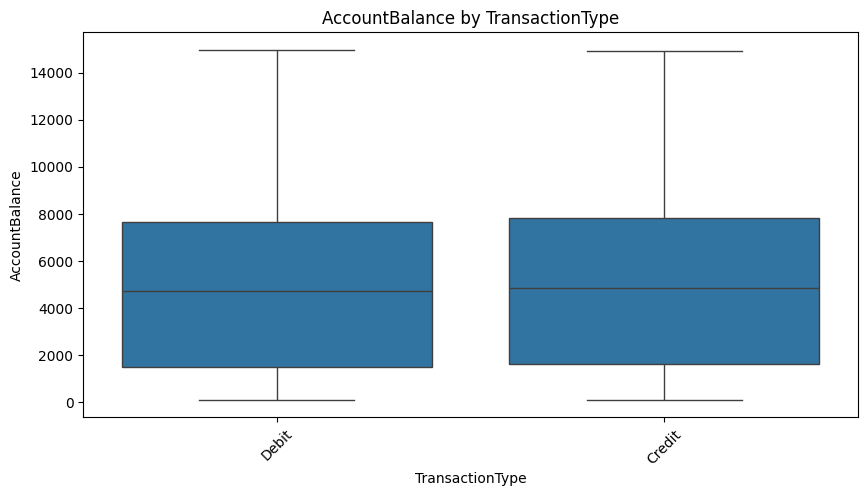

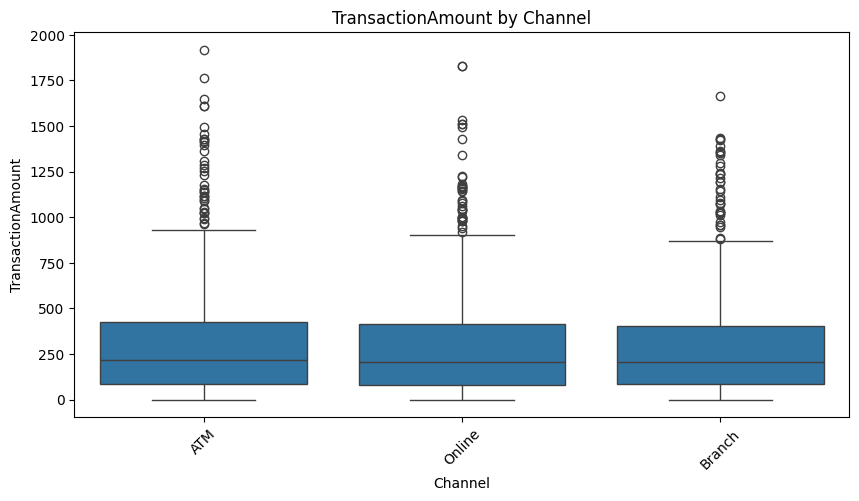

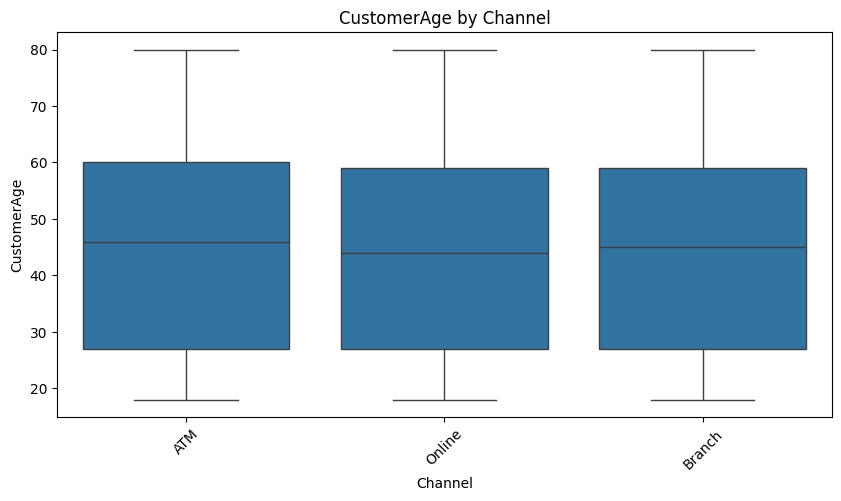

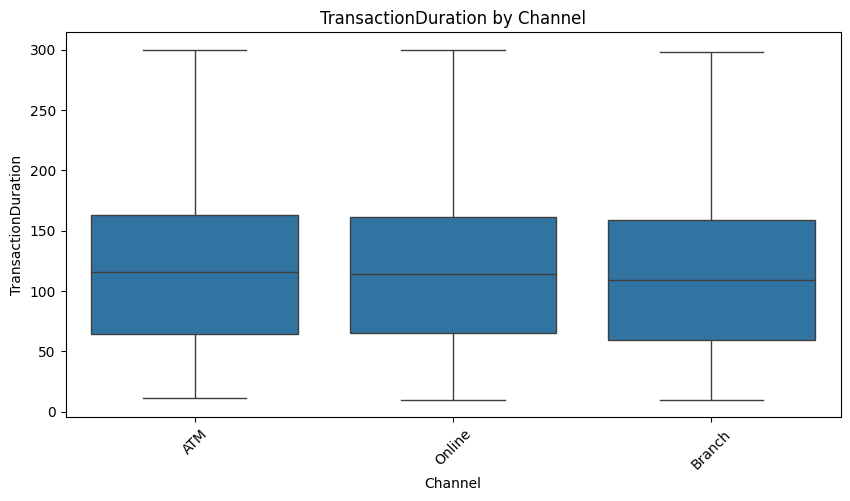

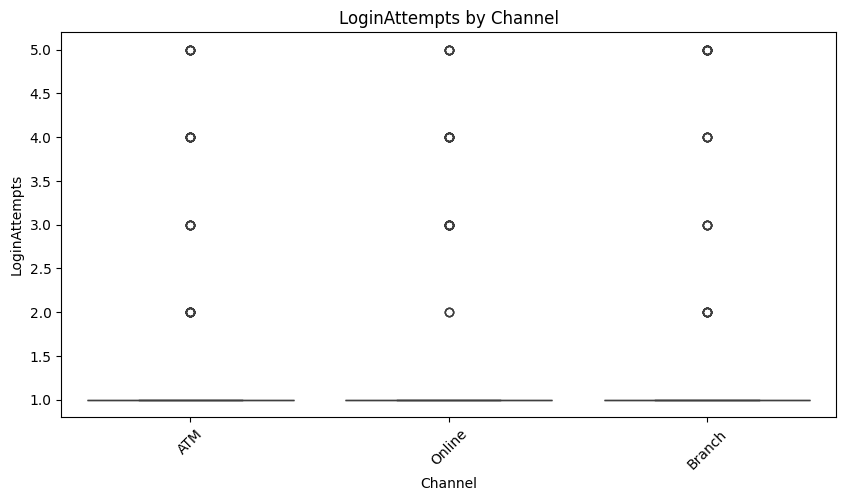

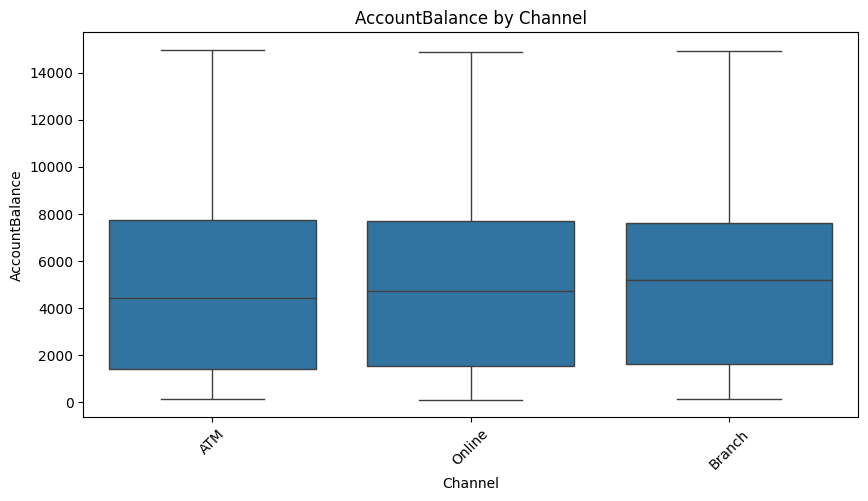

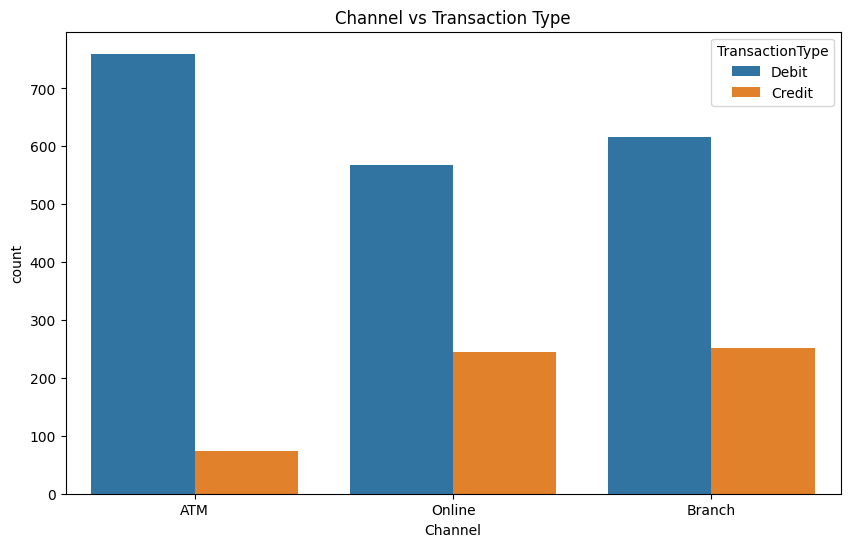

In [ ]:
numeric_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']
categorical_cols = ['TransactionType', 'Location', 'Channel', 'CustomerOccupation']

plt.figure(figsize=(10, 6))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

important_pairs = [
    ('TransactionAmount', 'AccountBalance'),
    ('TransactionAmount', 'TransactionDuration'),
    ('LoginAttempts', 'TransactionDuration')
]

for x, y in important_pairs:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=data[x], y=data[y], alpha=0.6)
    plt.title(f'{x} vs {y}')
    plt.show()

#  3. BOXPLOTS (NUMERIC vs CATEGORICAL)
important_cat = ['TransactionType', 'Channel']

for cat in important_cat:
    for num in numeric_cols:
        plt.figure(figsize=(10, 5))
        sns.boxplot(x=cat, y=num, data=data)
        plt.title(f'{num} by {cat}')
        plt.xticks(rotation=45)
        plt.show()

# 4. CATEGORICAL vs CATEGORICAL

plt.figure(figsize=(10, 6))
sns.countplot(x='Channel', hue='TransactionType', data=data)
plt.title('Channel vs Transaction Type')
plt.show()


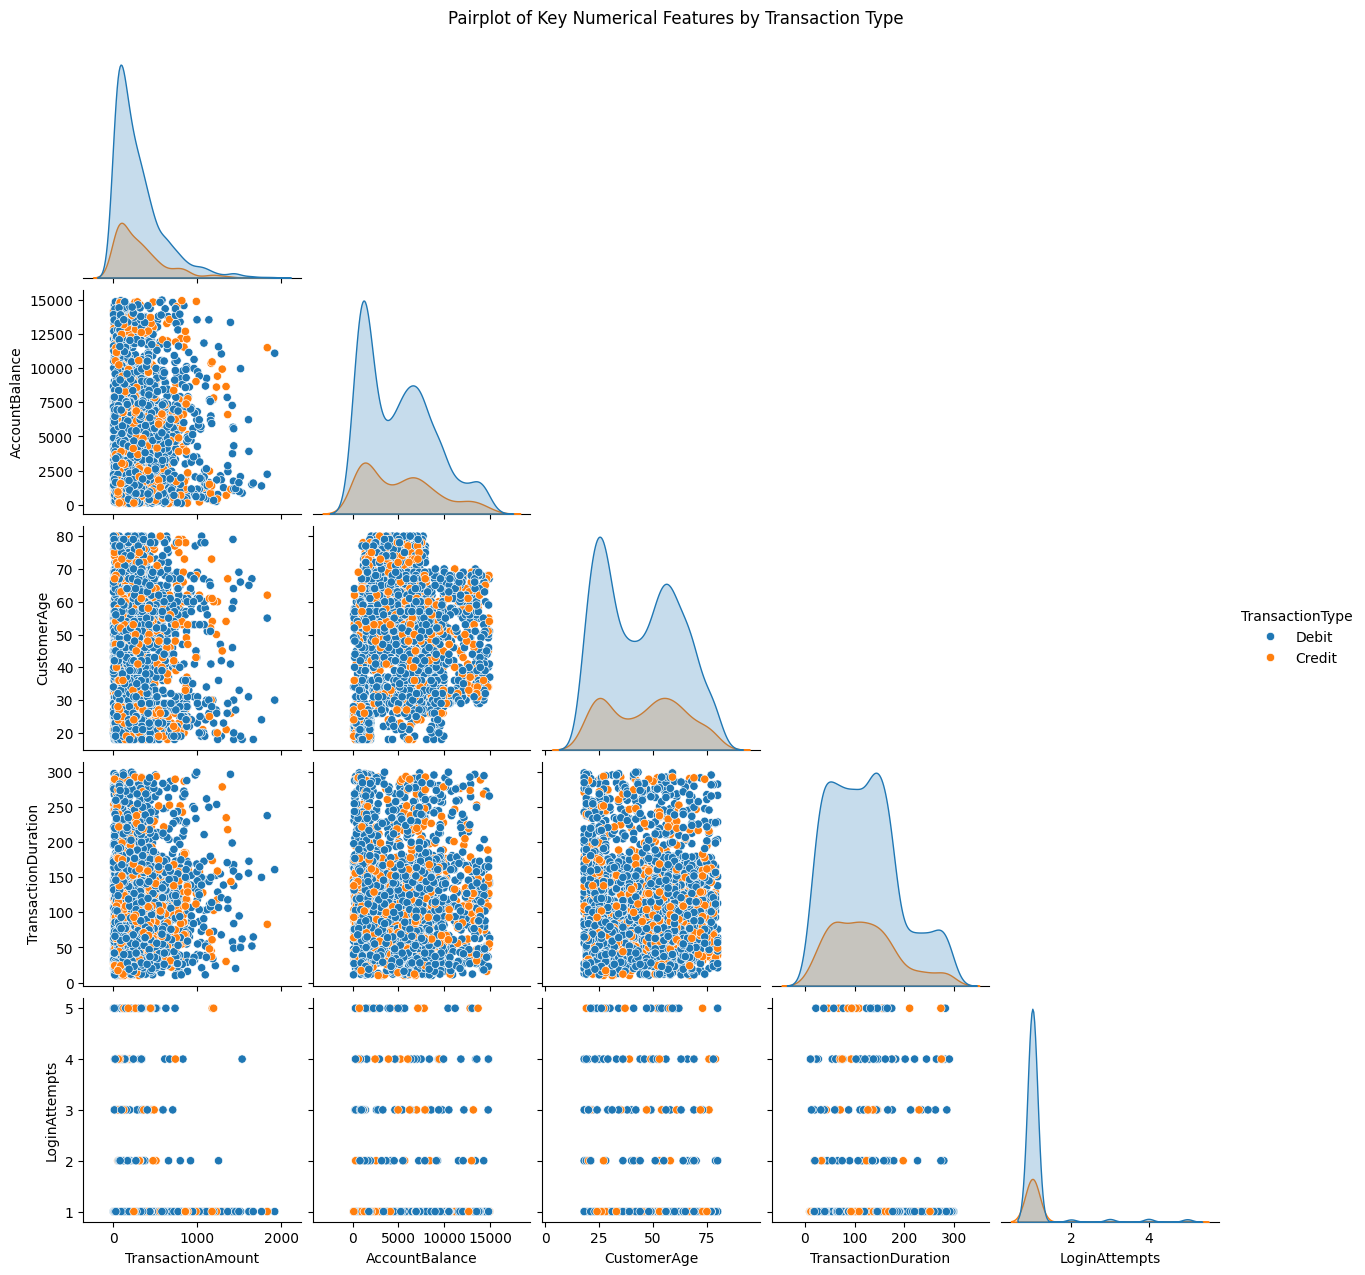

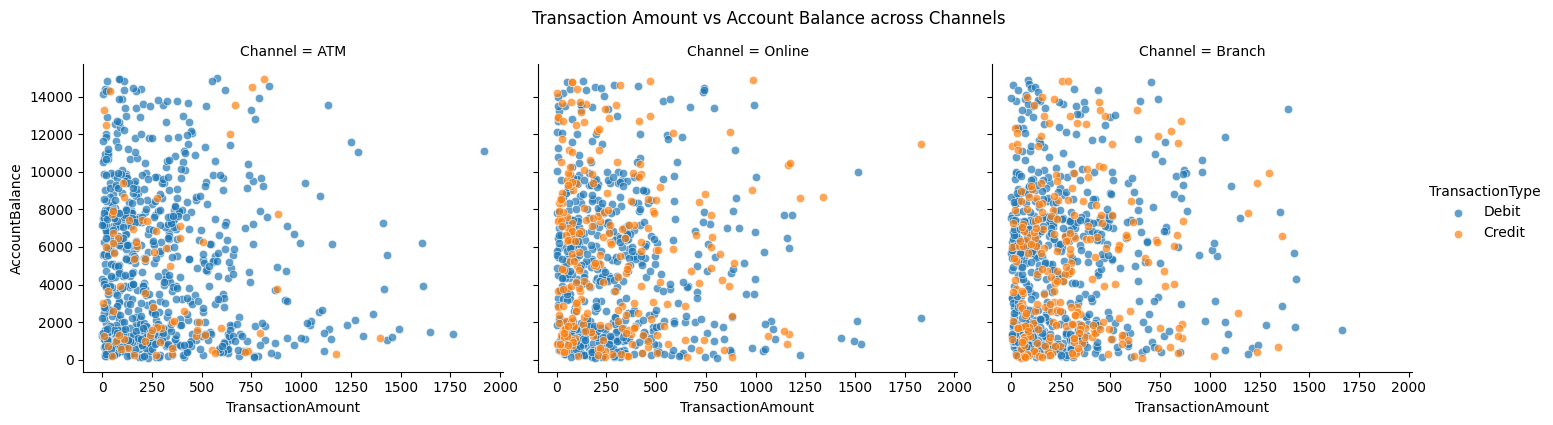

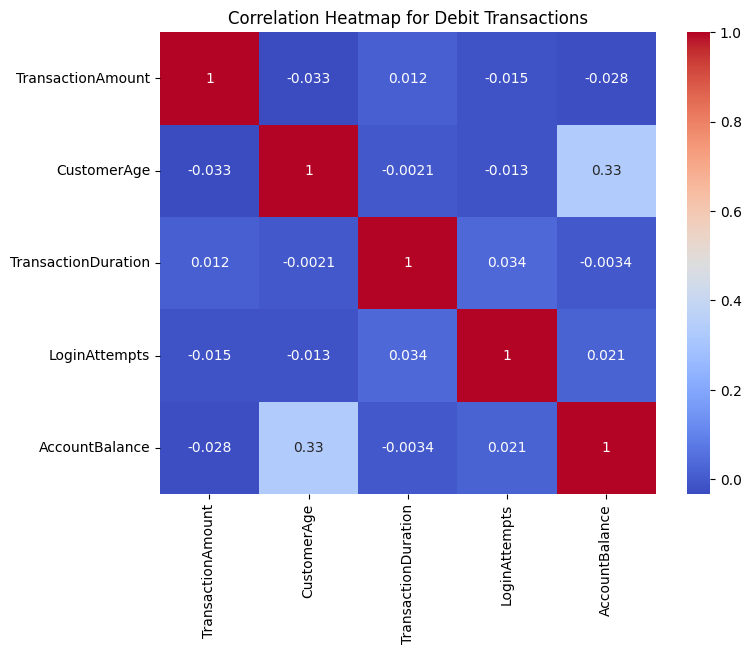

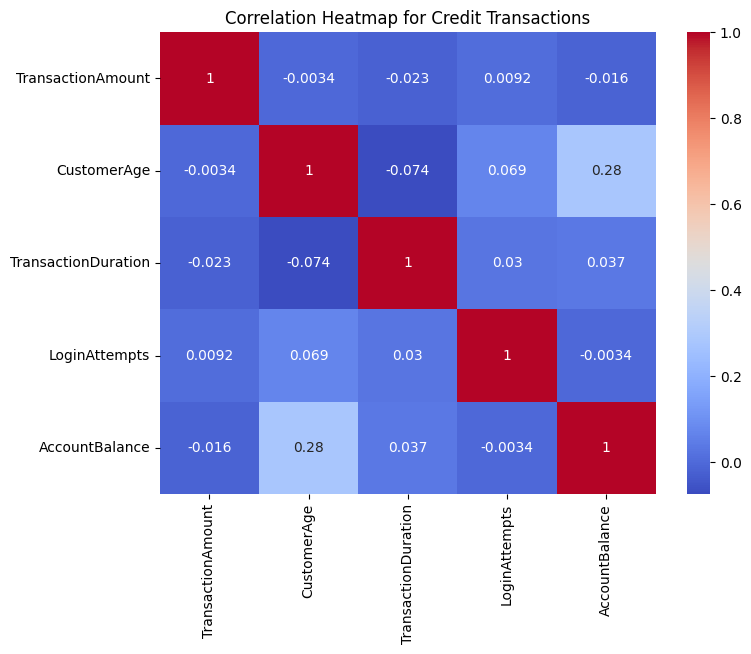

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_numeric = ['TransactionAmount', 'AccountBalance','CustomerAge', 'TransactionDuration', 'LoginAttempts']

sns.pairplot(
    data,
    vars=selected_numeric,
    hue='TransactionType',
    corner=True
)

plt.suptitle('Pairplot of Key Numerical Features by Transaction Type', y=1.02)
plt.show()
g = sns.FacetGrid(
    data,
    col="Channel",
    hue="TransactionType",
    height=4,
    aspect=1.2
)

g.map(sns.scatterplot, "TransactionAmount", "AccountBalance", alpha=0.7)
g.add_legend()

g.fig.suptitle(
    'Transaction Amount vs Account Balance across Channels',
    y=1.05
)

plt.show()

transaction_types = ['debit', 'credit']

for t_type in transaction_types:
    subset = data[data['TransactionType'].str.lower() == t_type]

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        subset[numeric_cols].corr(),
        annot=True,
        cmap='coolwarm'
    )

    plt.title(f'Correlation Heatmap for {t_type.capitalize()} Transactions')
    plt.show()

In [ ]:
data['TransactionDate'] = pd.to_datetime(data['TransactionDate'])
data['PreviousTransactionDate'] = pd.to_datetime(data['PreviousTransactionDate'])
data['TimeSinceLastTransaction'] = (
    data['TransactionDate'] - data['PreviousTransactionDate']
).dt.total_seconds()

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(numeric_scaled)

    score = silhouette_score(numeric_scaled, labels)
    scores.append(score)

    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.22708671021079566
K=3, Silhouette Score=0.21545608701800226
K=4, Silhouette Score=0.24044069676383847
K=5, Silhouette Score=0.25541846640056654
K=6, Silhouette Score=0.2624845436472968
K=7, Silhouette Score=0.2377182175534654
K=8, Silhouette Score=0.22462486347000665
K=9, Silhouette Score=0.2343222247737526


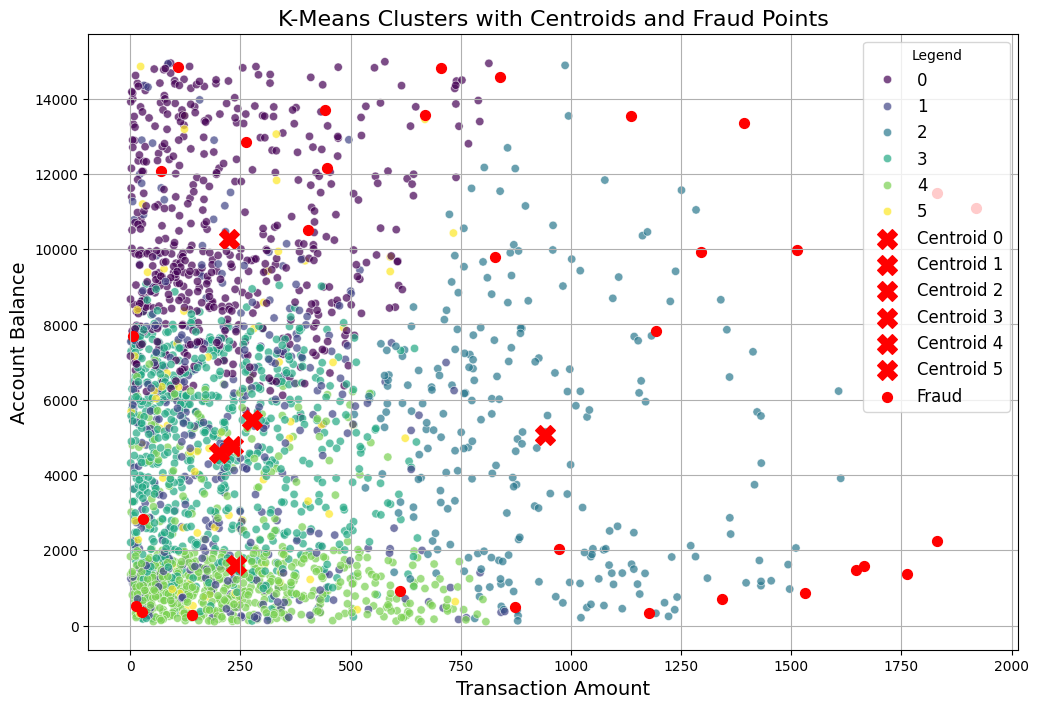

Total Fraudulent Transactions Detected (Using K Means clustering): 32


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['TransactionAmount', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'CustomerAge']

scaler = StandardScaler()
numeric_scaled = pd.DataFrame(scaler.fit_transform(data[numeric_cols]), columns=numeric_cols)

kmeans = KMeans(n_init='auto')
kmeans.fit(numeric_scaled)
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(numeric_scaled)
data['KMeans_Cluster'] = kmeans_labels

centroids = kmeans.cluster_centers_
distances = np.linalg.norm(numeric_scaled.values - centroids[kmeans_labels], axis=1)
data['KMeans_Distance'] = distances

threshold = distances.mean() + 3 * distances.std()
data['KMeans_Fraud'] = distances > threshold

fraud_summary = data['KMeans_Fraud'].value_counts()

centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

distances = np.linalg.norm(numeric_scaled - centroids_scaled[kmeans_labels], axis=1)
threshold = distances.mean() + 3 * distances.std()
data['Fraud'] = distances > threshold
data['KMeans_Distance'] = distances

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=data['TransactionAmount'],
    y=data['AccountBalance'],
    hue=data['KMeans_Cluster'],
    palette='viridis',
    alpha=0.7,
    legend='full'
)

for i, centroid in enumerate(centroids_original):
    plt.scatter(
        centroid[numeric_cols.index('TransactionAmount')],
        centroid[numeric_cols.index('AccountBalance')],
        color='red',
        marker='X',
        s=200,
        label=f'Centroid {i}'
    )

fraud_points = data[data['Fraud']]
plt.scatter(
    fraud_points['TransactionAmount'],
    fraud_points['AccountBalance'],
    color='red',
    marker='o',
    s=50,
    label='Fraud'
)

plt.title('K-Means Clusters with Centroids and Fraud Points', fontsize=16)
plt.xlabel('Transaction Amount', fontsize=14)
plt.ylabel('Account Balance', fontsize=14)
plt.legend(title='Legend', fontsize=12)
plt.grid(True)
plt.show()

total_fraud_points = data['Fraud'].sum()
print(f"Total Fraudulent Transactions Detected (Using K Means clustering): {total_fraud_points}")


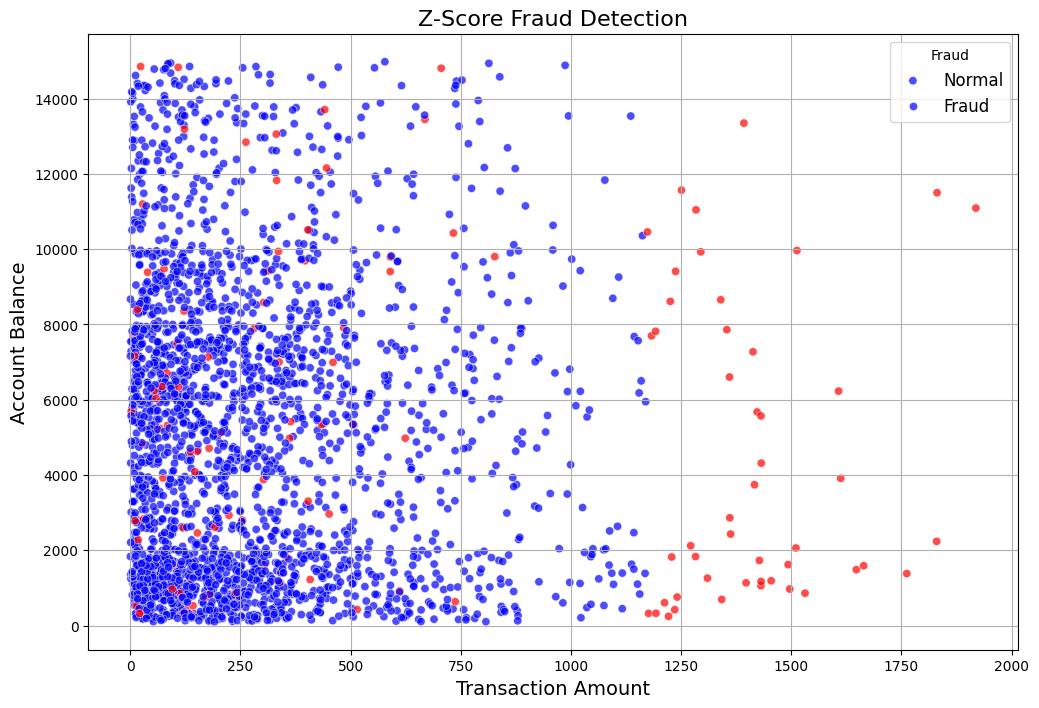

Total Fraudulent Transactions Detected by Z-Score Analysis: 140


In [ ]:
from scipy.stats import zscore

numeric_cols = ['TransactionAmount', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'CustomerAge']

z_scores = np.abs(zscore(data[numeric_cols]))
data['ZScore_Fraud'] = (z_scores > 3).any(axis=1)

zscore_fraud_points = data[data['ZScore_Fraud']]

total_zscore_fraud_points = data['ZScore_Fraud'].sum()

data['Fraud'] |= data['ZScore_Fraud']

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=data['TransactionAmount'],
    y=data['AccountBalance'],
    hue=data['ZScore_Fraud'],
    palette={True: 'red', False: 'blue'},
    alpha=0.7
)
plt.title('Z-Score Fraud Detection', fontsize=16)
plt.xlabel('Transaction Amount', fontsize=14)
plt.ylabel('Account Balance', fontsize=14)
plt.legend(title='Fraud', labels=['Normal', 'Fraud'], fontsize=12)
plt.grid(True)
plt.show()

zscore_fraud_output_path = 'bank_transactions_data_2.csv'
zscore_fraud_points.to_csv(zscore_fraud_output_path, index=False)

print(f"Total Fraudulent Transactions Detected by Z-Score Analysis: {total_zscore_fraud_points}")

Classification Report:
              precision    recall  f1-score   support

       False       0.99      1.00      1.00       714
        True       1.00      0.85      0.92        40

    accuracy                           0.99       754
   macro avg       1.00      0.93      0.96       754
weighted avg       0.99      0.99      0.99       754



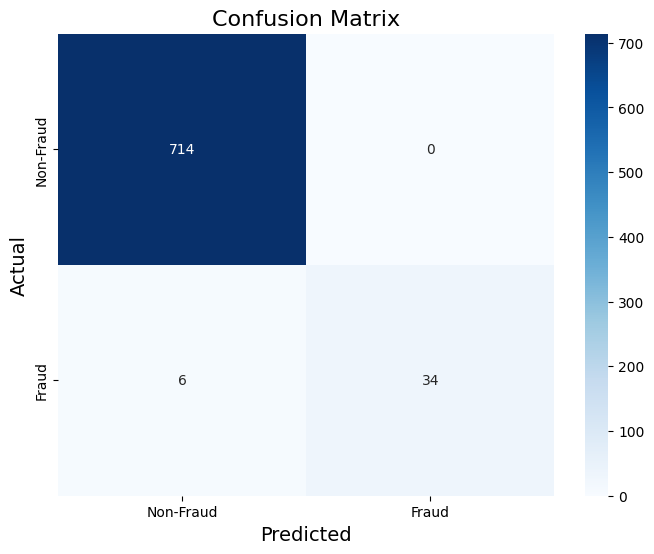

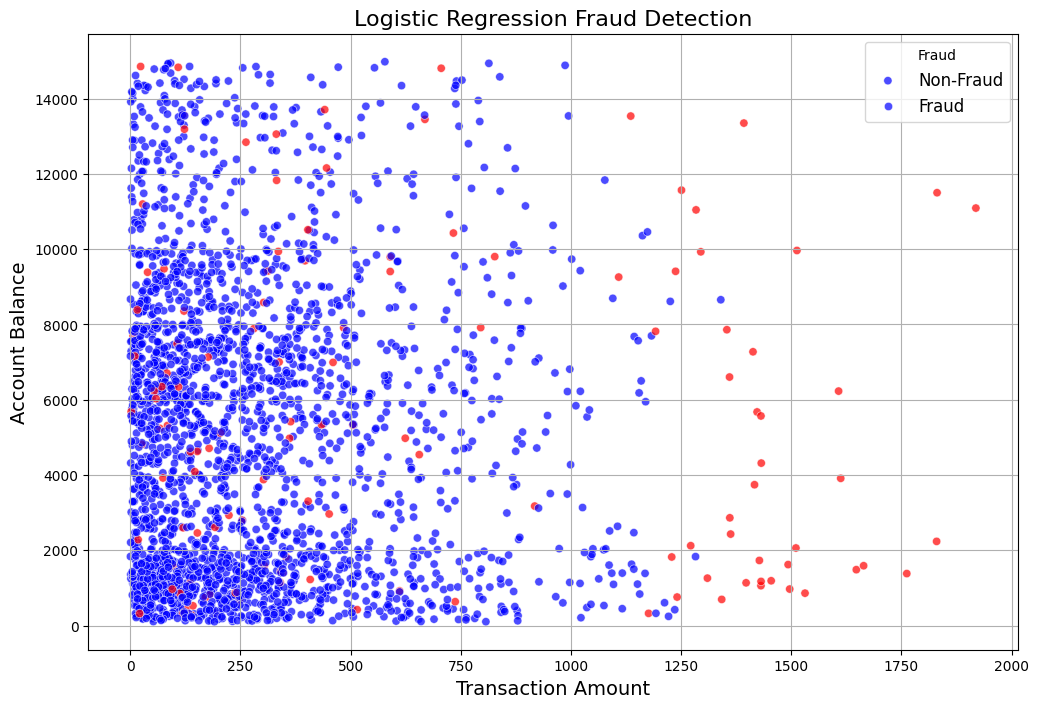

Total Fraudulent Transactions Detected by Logistic Regression: 132
Fraudulent transactions saved to: bank_transactions_data_2.csv


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

features = ['TransactionAmount', 'TransactionDuration', 'LoginAttempts', 'AccountBalance','CustomerAge','TimeSinceLastTransaction']
target = 'Fraud'

X = data[features]
y = data[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.show()

data['LogReg_Fraud'] = log_reg.predict(X_scaled)
data['Fraud'] |= data['LogReg_Fraud']

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=data['TransactionAmount'],
    y=data['AccountBalance'],
    hue=data['LogReg_Fraud'],
    palette={1: 'red', 0: 'blue'},
    alpha=0.7
)
plt.title('Logistic Regression Fraud Detection', fontsize=16)
plt.xlabel('Transaction Amount', fontsize=14)
plt.ylabel('Account Balance', fontsize=14)
plt.legend(title='Fraud', labels=['Non-Fraud', 'Fraud'], fontsize=12)
plt.grid(True)
plt.show()

log_reg_fraud_output_path = 'bank_transactions_data_2.csv'
log_reg_fraud_points = data[data['LogReg_Fraud'] == 1]
log_reg_fraud_points.to_csv(log_reg_fraud_output_path, index=False)

total_log_reg_fraud_points = log_reg_fraud_points.shape[0]
print(f"Total Fraudulent Transactions Detected by Logistic Regression: {total_log_reg_fraud_points}")
print(f"Fraudulent transactions saved to: {log_reg_fraud_output_path}")

In [ ]:
# Save FULL dataset with all fraud flags
data.to_csv('bank_transactions_final.csv', index=False)

print("Dataset saved with Fraud column")
data[data['Fraud'] == True]

Dataset saved with Fraud column


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,...,LoginAttempts,AccountBalance,PreviousTransactionDate,TimeSinceLastTransaction,KMeans_Cluster,KMeans_Distance,KMeans_Fraud,Fraud,ZScore_Fraud,LogReg_Fraud
23,TX000024,AC00453,345.84,2023-05-02 18:25:46,Debit,Fort Worth,D000162,191.82.103.198,M083,Online,...,3,1402.50,2024-11-04 08:07:04,-47655678.0,5,2.361904,False,True,True,True
26,TX000027,AC00441,246.93,2023-04-17 16:37:01,Debit,Miami,D000046,55.154.161.250,M029,ATM,...,5,673.35,2024-11-04 08:11:38,-48958477.0,5,2.412329,False,True,True,True
32,TX000033,AC00060,396.45,2023-09-25 16:26:00,Debit,New York,D000621,133.67.250.163,M007,ATM,...,3,9690.15,2024-11-04 08:11:13,-35048713.0,5,2.118263,False,True,True,True
38,TX000039,AC00478,795.31,2023-10-12 17:07:40,Debit,Mesa,D000077,49.29.37.185,M048,ATM,...,2,7914.88,2024-11-04 08:11:17,-33577417.0,2,2.187546,False,True,False,True
74,TX000075,AC00265,1212.51,2023-10-04 16:36:29,Debit,Indianapolis,D000231,193.83.0.183,M036,Branch,...,1,605.95,2024-11-04 08:06:51,-34270222.0,2,2.462875,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2403,TX002404,AC00111,1493.00,2023-06-07 17:05:41,Debit,Colorado Springs,D000344,136.162.111.135,M096,ATM,...,1,1619.16,2024-11-04 08:07:07,-44550086.0,2,2.495693,False,True,True,True
2414,TX002415,AC00028,1664.33,2023-09-25 17:11:19,Debit,San Antonio,D000072,116.106.207.139,M064,Branch,...,1,1588.31,2024-11-04 08:07:07,-35045748.0,2,3.161818,True,True,True,True
2423,TX002424,AC00340,332.06,2023-06-21 16:38:54,Debit,Seattle,D000365,94.37.250.128,M086,ATM,...,4,11826.52,2024-11-04 08:06:23,-43342049.0,5,2.255204,False,True,True,True
2445,TX002446,AC00439,403.01,2023-09-04 17:32:35,Debit,Washington,D000677,223.32.70.156,M029,Online,...,3,10513.52,2024-11-04 08:09:32,-36859017.0,5,3.257355,True,True,True,True


In [ ]:
from google.colab import files
files.download('bank_transactions_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

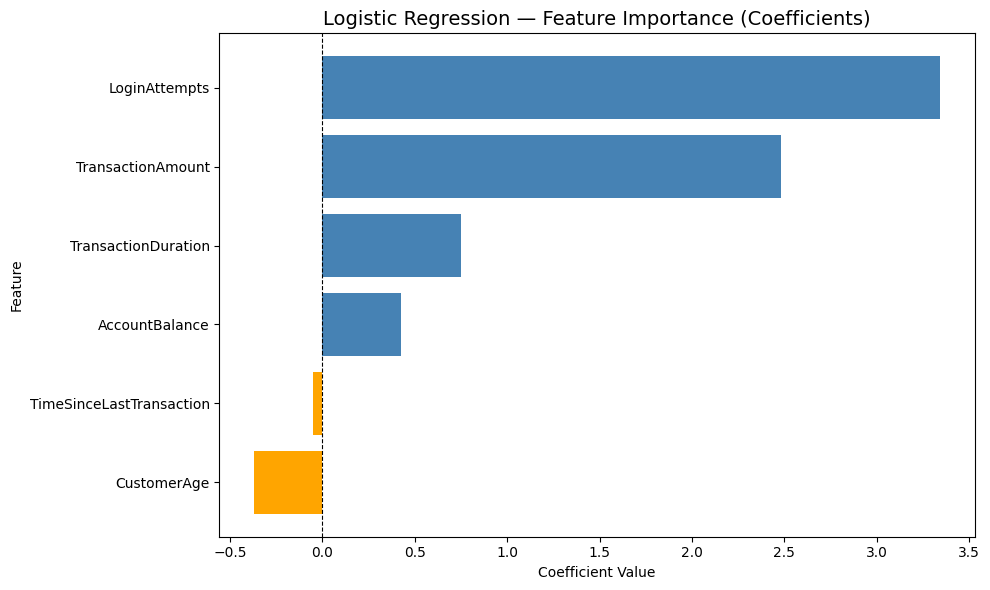

Feature Importance Ranking:
                 Feature  Coefficient
           LoginAttempts     3.344531
       TransactionAmount     2.483305
     TransactionDuration     0.748690
          AccountBalance     0.423650
TimeSinceLastTransaction    -0.051908
             CustomerAge    -0.371945


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

feature_names = ['TransactionAmount', 'TransactionDuration',
                 'LoginAttempts', 'AccountBalance',
                 'CustomerAge', 'TimeSinceLastTransaction']

coefficients = log_reg.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if c > 0 else 'orange' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Logistic Regression — Feature Importance (Coefficients)', fontsize=14)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Feature Importance Ranking:")
print(coef_df.sort_values('Coefficient', ascending=False).to_string(index=False))

In [ ]:
new_data = pd.DataFrame([
    {
        'TransactionAmount': 50000,
        'TransactionDuration': 120,
        'LoginAttempts': 3,
        'AccountBalance': 2000,
        'CustomerAge': 45,
        'TimeSinceLastTransaction': 3600
    },
    {
        'TransactionAmount': 200,
        'TransactionDuration': 20,
        'LoginAttempts': 1,
        'AccountBalance': 50000,
        'CustomerAge': 30,
        'TimeSinceLastTransaction': 100
    },
    {
        'TransactionAmount': 90000,
        'TransactionDuration': 300,
        'LoginAttempts': 6,
        'AccountBalance': 1000,
        'CustomerAge': 50,
        'TimeSinceLastTransaction': 50
    },
    {'TransactionAmount': 75000, 'TransactionDuration': 250, 'LoginAttempts': 4, 'AccountBalance': 1500, 'CustomerAge': 40, 'TimeSinceLastTransaction': 200},
    {'TransactionAmount': 100, 'TransactionDuration': 10, 'LoginAttempts': 1, 'AccountBalance': 80000, 'CustomerAge': 25, 'TimeSinceLastTransaction': 5000},
    {'TransactionAmount': 60000, 'TransactionDuration': 180, 'LoginAttempts': 5, 'AccountBalance': 3000, 'CustomerAge': 35, 'TimeSinceLastTransaction': 60},
    {'TransactionAmount': 15000, 'TransactionDuration': 60,  'LoginAttempts': 2, 'AccountBalance': 12000, 'CustomerAge': 28, 'TimeSinceLastTransaction': 800},
    {'TransactionAmount': 82000, 'TransactionDuration': 240, 'LoginAttempts': 5, 'AccountBalance': 1800,  'CustomerAge': 47, 'TimeSinceLastTransaction': 90},
    {'TransactionAmount': 300,   'TransactionDuration': 15,  'LoginAttempts': 1, 'AccountBalance': 60000, 'CustomerAge': 22, 'TimeSinceLastTransaction': 5000},
    {'TransactionAmount': 67000, 'TransactionDuration': 200, 'LoginAttempts': 4, 'AccountBalance': 2500,  'CustomerAge': 39, 'TimeSinceLastTransaction': 150},
    {'TransactionAmount': 1200,  'TransactionDuration': 30,  'LoginAttempts': 2, 'AccountBalance': 40000, 'CustomerAge': 33, 'TimeSinceLastTransaction': 2000},
    {'TransactionAmount': 95000, 'TransactionDuration': 320, 'LoginAttempts': 7, 'AccountBalance': 900,   'CustomerAge': 52, 'TimeSinceLastTransaction': 40},
    {'TransactionAmount': 45000, 'TransactionDuration': 150, 'LoginAttempts': 3, 'AccountBalance': 5000,  'CustomerAge': 36, 'TimeSinceLastTransaction': 300},
    {'TransactionAmount': 700,   'TransactionDuration': 20,  'LoginAttempts': 1, 'AccountBalance': 70000, 'CustomerAge': 26, 'TimeSinceLastTransaction': 7000},
    {'TransactionAmount': 88000, 'TransactionDuration': 280, 'LoginAttempts': 6, 'AccountBalance': 1100,  'CustomerAge': 49, 'TimeSinceLastTransaction': 70},
    {'TransactionAmount': 2500,  'TransactionDuration': 40,  'LoginAttempts': 2, 'AccountBalance': 35000, 'CustomerAge': 31, 'TimeSinceLastTransaction': 1200}

])

In [ ]:
features = ['TransactionAmount', 'TransactionDuration',
            'LoginAttempts', 'AccountBalance',
            'CustomerAge', 'TimeSinceLastTransaction']

new_data = new_data[features]

In [ ]:
new_scaled = scaler.transform(new_data)

In [ ]:
predictions = log_reg.predict(new_scaled)
probabilities = log_reg.predict_proba(new_scaled)[:, 1]

In [ ]:
results = new_data.copy()

results['Fraud_Prediction'] = predictions
results['Fraud_Probability'] = probabilities

results

,TransactionAmount,TransactionDuration,LoginAttempts,AccountBalance,CustomerAge,TimeSinceLastTransaction,Fraud_Prediction,Fraud_Probability
0,50000,120,3,2000,45,3600,True,1.000000
1,200,20,1,50000,30,100,False,0.006478
2,90000,300,6,1000,50,50,True,1.000000
3,75000,250,4,1500,40,200,True,1.000000
4,100,10,1,80000,25,5000,False,0.067394
5,60000,180,5,3000,35,60,True,1.000000
6,15000,60,2,12000,28,800,True,1.000000
7,82000,240,5,1800,47,90,True,1.000000
8,300,15,1,60000,22,5000,False,0.048240
9,67000,200,4,2500,39,150,True,1.000000
